# Notebook Documentation

This notebook performs various operations related to atmospheric data processing and analysis. It utilizes `numpy` for numerical operations and `xarray` for handling NetCDF files.

It sets up test and run parameters, defines file paths, and opens input NetCDF files. 

The notebook also samples fluctuations in relative humidity values, updates the dataset with these sampled values, and sets initial environmental conditions for contrail formation. 

Finally, it saves the modified dataset to new NetCDF files to be used as meteorological input files to APCEMM.


# Import file and filepaths

Standard deviation of the ensemble mean of specific humidity uncertainty: 0.805274767096976
Area under the curve of the fitted PDF: 0.9802984427441686
Mean of the ensemble mean of specific humidity uncertainty: 14.613933633602585


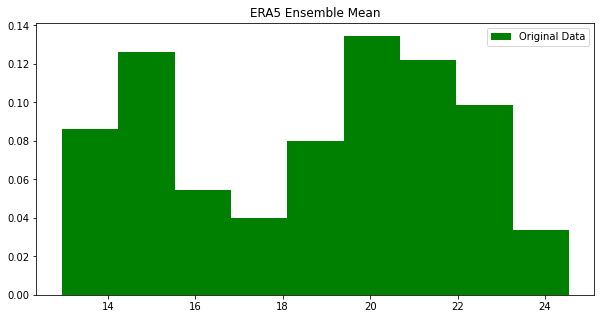

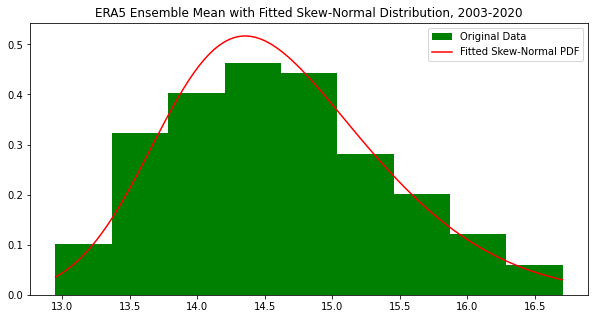

In [1]:
import numpy as np
import xarray as xr
import nbformat
import scipy.stats as stats
import shutil
import yaml
import os
import re
import subprocess

# Import variables form ensemble means 
# Load the notebook
notebook_path = '/home/chinahg/GCresearch/contrailuncertainty/ERA5_processing/ERA5_ensemble_means.ipynb'
with open(notebook_path) as f:
    notebook = nbformat.read(f, as_version=4)

# Extract the code cells
code_cells = [cell for cell in notebook.cells if cell.cell_type == 'code']

# Execute the code cells to import the variable
for cell in code_cells:
    exec(cell.source)

# NOTE: You must create directories for the output files before running the script. In this case, 
# create a directory called 'output' in the same directory as this script, with a nested directory called 'test_X'. 
# X is the number of the test.

# Function Library

In [2]:
### Function Library ###

def generate_apcemm_input_files(num_met_files, test_num, set_type):
    # Set up output path
    if set_type == "validation":
        out_path = '/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_{}/inputs/{}/APCEMM_met_validation_{}.nc'
    else:
        out_path = '/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_{}/inputs/{}/APCEMM_met_{}.nc'
    output_file_template = out_path

    for run_num in range(1,num_met_files+1):
        # Sample initial condition, throwing out entries under threshold
        low_RHi_IC = True
        while low_RHi_IC == True:
            # Sample stochastic RHi initial condition
            RHi_IC = np.round(np.random.normal(mean_norm, sigma_norm, size=1) + IC_scaled_mean, 2)
            if RHi_IC[0] >= 117:
                low_RHi_IC = False

        # Sample RHi values for the rest of the timesteps, checking for negative values
        flag_negative = True
        while flag_negative == True:
            # Sample fluctuations in RH values, centered around IC mean from ERA5 ensembles
            RHi_time_samples = np.round(np.random.normal(mean_norm_time, sigma_norm_time, size=timesteps-1) + RHi_IC[0], 2)

            # Check if RH_sampled has any zero or negative values
            if np.any(RHi_time_samples <= 0):
                flag_negative = True
                print("RHi_sampled contains zero or negative values.")
            else:
                flag_negative = False

        # Consolidate the sampled RHi values into a matrix
        RHi_time = np.append(RHi_IC, RHi_time_samples)

        RHi_sampled_matrix = np.tile(RHi_time, (16, 1)) # Replacing only 16 altitude layers with samples. The rest are predefined as subsaturated.

        # Replace the 250 hPa row of ds with the sampled RH timeseries
        ds['relative_humidity_ice'][90:106, :] = RHi_sampled_matrix

        # Save the changes to new output files
        output_file_path = output_file_template.format(test_num, set_type, run_num)
        ds.to_netcdf(output_file_path)
        ds.close()
        print("Output file saved to: {}".format(output_file_path))

        # Generate associated YAML file
        generate_yaml_file(test_num, set_type, run_num)

# Now we can update the YAML base file to call the new met files
def generate_yaml_file(test_num, set_type, run_num):
    # Define source and destination paths
    source_path = "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/BASE_APCEMM_input.yaml"  # Source YAML file
    destination_dir = "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_{}/inputs/{}".format(test_num, set_type)  # Target directory
    destination_path = os.path.join(destination_dir, "APCEMM_input_run_{}.yaml".format(run_num))

    # Copy the YAML file to the new directory
    shutil.copy(source_path, destination_path)

    # Read and modify the copied YAML file
    with open(destination_path, "r") as file:
        data = yaml.safe_load(file)  # Load YAML into a Python dictionary

    # Modify the YAML content
    data["SIMULATION MENU"]["OUTPUT SUBMENU"]["Output folder (string)"] = "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_{}/outputs/{}/test_{}_run_{}".format(test_num, set_type, test_num, run_num)

    if set_type == "training":
        data["METEOROLOGY MENU"]["METEOROLOGICAL INPUT SUBMENU"]["Met input file path (string)"] = "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_{}/inputs/{}/APCEMM_met_{}.nc".format(test_num, set_type, run_num)
    else:
        data["METEOROLOGY MENU"]["METEOROLOGICAL INPUT SUBMENU"]["Met input file path (string)"] = "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_{}/inputs/{}/APCEMM_met_validation_{}.nc".format(test_num, set_type, run_num)

    # Write the modified YAML back to the file
    with open(destination_path, "w") as file:
        yaml.dump(data, file, default_flow_style=False, indent=4)

    print(f"Edited YAML file saved at: {destination_path}")

# Define Constants and Paths

In [3]:
# Define the file paths
input_file_path = '/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/BASE_APCEMM_met.nc'

# Open the input NetCDF file
ds = xr.open_dataset(input_file_path)

In [4]:
set_type = "validation" # Is this data for validating or training the model? Choose "validation" or "training".

# Define the dataset dimensions
altitudes = 125
timesteps = 24

# Initial condition distribution details
mean_norm = 0
sigma_norm = 0.5
IC_scaled_mean = 117

# RHi temporal distribution details
sigma_norm_time = mean_ensemble_RHi
mean_norm_time = 0

num_met_files = 20 # Number of met and YAML files to generate
test_num = 2 # Test number the met and YAML files are associated with

In [ ]:
# Generate the met files
generate_apcemm_input_files(num_met_files, test_num, set_type)

# Housekeeping + updating the .sh script

In [6]:
# Now we create the directories needed for the output files
for i in range(1, num_met_files+1):
    output_dir = "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_{}/outputs/{}/test_{}_run_{}".format(test_num, set_type, test_num, i)
    os.makedirs(output_dir, exist_ok=False)

In [ ]:
# # Now we write a script to run the bash file using sbatch
# start_run = 1
# end_run = num_met_files

# run_range = "{"+str(start_run) + ".." + str(end_run)+"}"

# # Define the path to the Bash script
# script_path = "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/run_apcemm.sh"  # Source bash file

# # Open the script file and read its content
# with open(script_path, 'r') as file:
#     script_content = file.read()

# modified_content = re.sub(r'{\d+..\d+}', run_range, script_content)

# # Write the modified content back to the script
# with open(script_path, 'w') as file:
#     file.write(modified_content)

# print("Bash script modified successfully.")

Bash script modified successfully.


# Run the bash script for batch APCEMM execution

In [ ]:
# Run the bash script
# os.system("sbatch {}".format(script_path))
# print("Bash script executed successfully.")

Bash script executed successfully.


sbatch: error: Batch job submission failed: Requested node configuration is not available


In [ ]:
# run the bash script the dumb way: VALIDATION NEXT
start_run = 1
end_run = 20

for i in range(start_run, end_run+1):
    arg1 = str(i)
    arg2 = set_type
    arg3 = str(test_num)
    subprocess.run(["sbatch", "--export=ARG1="+arg1+",ARG2="+arg2+",ARG3="+arg3, "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/run_apcemm.sh"])

Submitted batch job 489234
Submitted batch job 489235
Submitted batch job 489236
Submitted batch job 489237
Submitted batch job 489238
Submitted batch job 489239
Submitted batch job 489240
Submitted batch job 489241
Submitted batch job 489242
Submitted batch job 489243
Submitted batch job 489244
Submitted batch job 489245
Submitted batch job 489246
Submitted batch job 489247
Submitted batch job 489248
Submitted batch job 489249
Submitted batch job 489250
Submitted batch job 489251
Submitted batch job 489252
Submitted batch job 489253
